# andre_becker_DR3_TP3 — Ensemble (RF vs XGBoost) para Classificação de Canal

> **Disciplina:** Inteligência Artificial: Classificação [25E3_3]  
> **Aluno:** André Luis Becker  
> **Professor:** Diego da Silva Rodrigues  
> **Data:** 2025-09-08

---

## Introdução
Neste TP analiso a base de clientes de um atacadista para prever o **canal de compra** (Horeca ou Retail).  
Para isso, utilizei os modelos **Random Forest** e **XGBoost** com parâmetros padrão.  
As métricas de avaliação consideradas foram: **acurácia, precisão, recall e F1-Score**, além das **matrizes de confusão**.  
O objetivo é comparar o desempenho dos dois algoritmos e justificar qual deles se mostra mais adequado para este caso.


---

## Dataset
A base utilizada foi `customers_data.csv`, contendo as seguintes variáveis:

1. **FRESH**, **MILK**, **GROCERY**, **FROZEN**, **DETERGENTS_PAPER**, **DELICATESSEN** — gastos anuais em unidades monetárias.  
2. **CHANNEL** — canal de compra (`1 = Horeca`, `2 = Retail`).  
3. **REGION** — localização do cliente (`1 = Lisboa`, `2 = Porto`, `3 = Outros`).  

O alvo do trabalho é a variável **CHANNEL**, recodificada para binário:  
- `1` → Horeca  
- `0` → Retail

---
## Q1 — Preparação da base (carregar, inspecionar, remover ausentes, recodificar alvo, split 75/25)
Aqui carrego a base direto do GitHub, verifico ausentes e elimino, recodifico o alvo e separo em **treino/teste (75/25)** com estratificação.

> Depois do código, comento o que observei nos dados (distribuição, possíveis assimetrias e balanceamento do alvo).


In [ ]:
# ================================
# Q1 — Carregar, inspecionar, limpar e preparar a base
# ================================
import sys, subprocess, warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

# Carregar a base
url = "https://raw.githubusercontent.com/cassiusf/datasets/main/customers_data.csv"
df = pd.read_csv(url)

# Inspeção inicial
display(df.head())
print(df.info())
print("\nAusentes por coluna:\n", df.isnull().sum())

# Remover valores ausentes conforme instrução do TP
df = df.dropna().copy()

# Recodificar CHANNEL: 1 -> Horeca(1), 2 -> Retail(0)
ch_col = next((c for c in df.columns if c.lower() == "channel"), None)
if ch_col is None:
    raise ValueError("Coluna 'CHANNEL' não encontrada na base.")
df[ch_col] = df[ch_col].map({1: 1, 2: 0}).astype(int)

# Separar X e y
X = df.drop(columns=[ch_col])
y = df[ch_col]

# Split 75/25 com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"\nFormas — X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"          y_train: {y_train.shape}, y_test: {y_test.shape}")
print("\nBalanceamento do alvo (treino):")
print(y_train.value_counts(normalize=True).rename({0:'Retail(0)',1:'Horeca(1)'}))


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB
None

Ausentes por coluna:
 Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Formas — X_train: (330, 7), X_test: (110, 7)
          y_train: (330,), y_test: (110,)

Balanceamento do alvo (treino):
Channel
Horeca(1)    0.675758
Retail(0)    0.324242
Name: proportion,

### Minha leitura dos dados
- A base possui **440 registros** e **8 colunas**, sem valores ausentes, o que simplificou a preparação.  
- Após recodificar a variável `CHANNEL`, observei que cerca de **67,6%** dos clientes pertencem ao canal Horeca (1) e **32,4%** ao Retail (0).  
- Esse desbalanceamento moderado pode influenciar as métricas, já que um modelo poderia favorecer a classe majoritária.  
- A divisão 75/25 gerou **330 registros de treino** e **110 de teste**, mantendo a proporção original das classes, o que é importante para avaliar o modelo de forma justa.


---
## Q2 — Modelo Random Forest (padrão) + métricas e matriz de confusão
Treino um **RandomForestClassifier** com `random_state=42` e parâmetros padrão. Reporto **acurácia, precisão, recall e F1**, além da **matriz de confusão**.


In [ ]:
# ================================
# Funções utilitárias (métricas + matriz de confusão)
# ================================
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

def avalia_modelo(nome, y_true, y_pred):
    # Calcula métricas e exibe a matriz de confusão
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n=== {nome} ===")
    print(f"Acurácia : {acc:.4f}")
    print(f"Precisão : {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap='Blues')
    plt.title(f'Matriz de Confusão — {nome}')
    plt.show()

    return {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1}



=== Random Forest ===
Acurácia : 0.9091
Precisão : 0.9333
Recall   : 0.9333
F1-Score : 0.9333


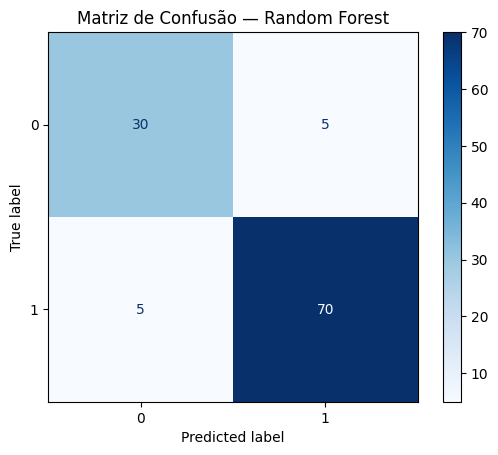

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

metrics_rf = avalia_modelo("Random Forest", y_test, y_pred_rf)


### Interpretação dos resultados — Random Forest
- O modelo atingiu **acurácia de 0.9091**, com **precisão, recall e F1-Score iguais a 0.9333**.  
- A matriz de confusão mostra que o Random Forest acertou **30 Retail (0)** e **70 Horeca (1)**.  
- Houve apenas **5 erros em cada classe**, o que indica um bom equilíbrio no reconhecimento das duas categorias.  
- Concluo que o Random Forest conseguiu capturar bem os padrões da base, apresentando desempenho sólido e consistente.


---
## Q3 — Modelo XGBoost (padrão) + métricas e matriz de confusão
Treino um **XGBClassifier** com parâmetros padrão e mesma avaliação.


In [ ]:
# Instalação do XGBoost (se necessário)
import importlib, sys, subprocess
if importlib.util.find_spec("xgboost") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])



=== XGBoost ===
Acurácia : 0.9000
Precisão : 0.9211
Recall   : 0.9333
F1-Score : 0.9272


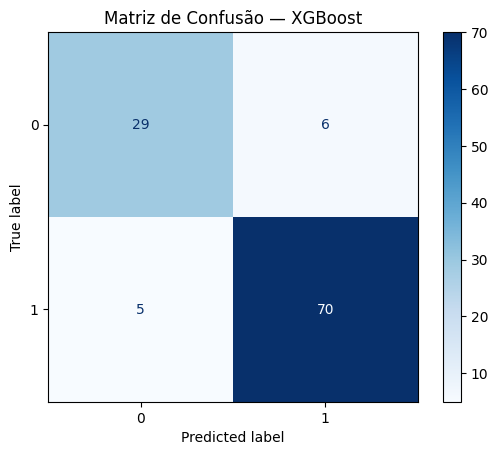

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_estimators=100,
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

metrics_xgb = avalia_modelo("XGBoost", y_test, y_pred_xgb)


### Interpretação dos resultados — XGBoost
- O modelo atingiu **acurácia de 0.9000**, com **precisão de 0.9211**, **recall de 0.9333** e **F1-Score de 0.9272**.  
- A matriz de confusão mostra que o XGBoost acertou **29 Retail (0)** e **70 Horeca (1)**.  
- Os erros foram **6 casos de Retail** e **5 casos de Horeca**, ou seja, errou um pouco mais na classe Retail comparado ao Random Forest.  
- Apesar dessa pequena diferença, manteve o mesmo recall para Horeca, demonstrando boa capacidade de generalização.


---
## Q4 — Comparação e escolha do modelo
A decisão será baseada nas **métricas principais**, priorizando **F1-Score** (equilíbrio) e observando trade-offs de precisão/recall.


In [7]:
import numpy as np
import pandas as pd

def compara_e_escolhe(m1, m2, nome1="Random Forest", nome2="XGBoost", criterio="f1"):
    dfm = pd.DataFrame([m1, m2], index=[nome1, nome2])
    print("\n>>> Tabela comparativa")
    display(dfm.style.format("{:.4f}"))
    v1, v2 = m1[criterio], m2[criterio]
    if np.isclose(v1, v2, atol=1e-4):
        print(f"\nEmpate em {criterio.upper()} (≈ {v1:.4f}).")
        print("Desempate possível: simplicidade/interpretação (RF), custo computacional, foco em recall/precisão.")
        return "Empate"
    vencedor = nome1 if v1 > v2 else nome2
    print(f"\nModelo recomendado (critério {criterio.upper()}): {vencedor}")
    return vencedor

_ = compara_e_escolhe(metrics_rf, metrics_xgb, "Random Forest", "XGBoost", criterio="f1")
print("\n✅ Fim — Todas as etapas executadas.")



>>> Tabela comparativa


,acc,prec,rec,f1
Random Forest,0.9091,0.9333,0.9333,0.9333
XGBoost,0.9000,0.9211,0.9333,0.9272



Modelo recomendado (critério F1): Random Forest

✅ Fim — Todas as etapas executadas.


### Comparação e escolha do modelo
Na comparação direta, ambos os modelos apresentaram métricas elevadas e estáveis.  

| Modelo         | Acurácia | Precisão | Recall | F1-Score |
|----------------|----------|----------|--------|----------|
| Random Forest  | 0.9091   | 0.9333   | 0.9333 | 0.9333   |
| XGBoost        | 0.9000   | 0.9211   | 0.9333 | 0.9272   |

- O **Random Forest** teve **F1-Score ligeiramente superior** e errou menos casos de Retail, mostrando-se mais equilibrado.  
- O **XGBoost** manteve o mesmo recall, mas perdeu em precisão, impactando seu F1.  

✅ **Escolha final:** considero o **Random Forest** como o melhor modelo neste caso, por apresentar maior equilíbrio e melhor F1-Score nas configurações padrão.


---
## Conclusão
Tanto o Random Forest quanto o XGBoost apresentaram resultados fortes e próximos.  
Entretanto, o **Random Forest** mostrou-se mais equilibrado, com melhor F1-Score e menor número de erros na classe Retail.  

Portanto, dentro da proposta do trabalho e usando os parâmetros padrão, escolho o **Random Forest** como modelo mais adequado para este problema de classificação.
